# 02. GTSRB Full PyTorch Workflow

In this notebook, we will build a complete PyTorch computer vision workflow for the German Traffic Sign Recognition project.

This notebook will move step by step from data understanding to model training and evaluation.

The main goal is not only to get high accuracy.  
The main goal is to learn the full PyTorch workflow clearly and make the notebook clean, reproducible, and project-like.

---

## What we're going to cover

1. Setup imports, paths, config, and helper file connection
2. Load CSV files and prepare image paths
3. Understand the dataset visually
4. Create train/validation split
5. Build PyTorch Dataset and DataLoader
6. Build a baseline CNN from scratch
7. Train the baseline model
8. Evaluate with curves, confusion matrix, and wrong predictions
9. Improve the model step by step
10. Save the best model and final outputs

> **Project rule:** We will not jump to advanced models before building a clean baseline.

## 1. Setup

Before working with the dataset, we need to prepare the notebook environment.

### 1.1 Guiding questions

- Which libraries do we need for this notebook?
- Can the notebook import our local helper file?
- Which device will PyTorch use?
- Where are the main project folders?
- What configuration values will control the first experiments?

In [1]:
from pathlib import Path
import sys
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

print("Imports completed.")

Imports completed.


In [2]:
# Detect current notebook directory
CURRENT_DIR = Path.cwd()

# If notebook is inside Notebook/, project root is parent
if CURRENT_DIR.name.lower() == "notebook":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

# Add project root to Python path so we can import from src/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Current directory:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)

Current directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Notebook
Project root: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition


In [3]:
from src import helper_functions as hf

print("Helper file imported successfully.")

Helper file imported successfully.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [5]:
DATA_DIR = PROJECT_ROOT / "Data"
PROCESSED_DATA_DIR = PROJECT_ROOT / "Processed_Data"
REPORT_DIR = PROJECT_ROOT / "Report"
TRAINED_MODEL_DIR = PROJECT_ROOT / "Trained_model"

IMAGE_SIZE = 64
BATCH_SIZE = 64
NUM_EPOCHS = 15
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
SEED = 42

NUM_WORKERS = 0
PIN_MEMORY = True if device == "cuda" else False

config = {
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "seed": SEED,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
}

print("Data directory:", DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Report directory:", REPORT_DIR)
print("Trained model directory:", TRAINED_MODEL_DIR)
print("\nConfig:")
config

Data directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Data
Processed data directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Processed_Data
Report directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Report
Trained model directory: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Trained_model

Config:


{'image_size': 64,
 'batch_size': 64,
 'num_epochs': 15,
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'seed': 42,
 'num_workers': 0,
 'pin_memory': True}

**What this shows:**  
The notebook can successfully connect to the project root, access the local `src/` folder, import the helper file, and use PyTorch with CUDA support.

**Why this matters:**  
This confirms that the project infrastructure is ready. The notebook is now connected to both the code side and the data side of the project. Since GPU is available, model training later should be much faster than CPU training.

**Decision:**  
We can now move from environment setup to dataset loading. The next step is to load the GTSRB CSV files, create full image paths, and verify that the image files can be accessed correctly.

## 2. Dataset Loading

In this section, we will load the GTSRB dataset information from the CSV files.

We will not load all images into memory yet.  
First, we will load the metadata tables and prepare image paths so that our PyTorch Dataset can load images later.

### Main goal of this section

By the end of this section, we should know:

- whether the CSV files load correctly
- whether image paths can be created correctly
- whether image paths exist on disk
- whether track IDs can be extracted for a better validation split

### 2.1 Reload helper functions

We are keeping repeated code inside `src/helper_functions.py`.

After editing the helper file, we need to reload it inside the notebook so the latest functions become available.

In [6]:
import importlib

importlib.reload(hf)

print("Helper functions reloaded.")

Helper functions reloaded.


### 2.2 Set seeds and create output folders

Before loading and preparing data, we will set random seeds for reproducibility.

We will also make sure that the project output folders exist.  
These folders will later store processed files, reports, figures, and trained models.

In [7]:
generator = hf.set_seeds(SEED)

hf.make_project_dirs(
    PROCESSED_DATA_DIR,
    REPORT_DIR,
    TRAINED_MODEL_DIR
)

print("Seeds set and output folders checked.")

Seeds set and output folders checked.


### 2.3 Load GTSRB CSV files

The dataset contains CSV files that describe image paths, image sizes, ROI coordinates, and class labels.

Here, we will load:

- `Train.csv`
- `Test.csv`
- `Meta.csv`

We will first check only the shapes to confirm that the files were loaded successfully.

In [8]:
train_df, test_df, meta_df = hf.load_gtsrb_csvs(DATA_DIR)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Meta shape:", meta_df.shape)

Train shape: (39209, 8)
Test shape: (12630, 8)
Meta shape: (43, 5)


### 2.4 Inspect CSV columns

Before using the CSV files, we need to understand which columns are available.

This helps us identify:

- the image path column
- the target label column
- the image size columns
- the ROI coordinate columns

In [9]:
print("Train columns:")
print(train_df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

print("\nMeta columns:")
print(meta_df.columns.tolist())

Train columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

Test columns:
['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

Meta columns:
['Path', 'ClassId', 'ShapeId', 'ColorId', 'SignId']


### 2.5 Create full image paths

The CSV files contain relative image paths such as `Train/20/...`.

For image loading, we need full paths that point to the actual image files on disk.

We will create a new column called `full_path`.

In [10]:
train_df = hf.add_full_image_path(train_df, DATA_DIR)
test_df = hf.add_full_image_path(test_df, DATA_DIR)
meta_df = hf.add_full_image_path(meta_df, DATA_DIR)

train_df[["Path", "full_path", "ClassId"]].head()

,Path,full_path,ClassId
0,Train/20/00020_00000_00000.png,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,20
1,Train/20/00020_00000_00001.png,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,20
2,Train/20/00020_00000_00002.png,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,20
3,Train/20/00020_00000_00003.png,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,20
4,Train/20/00020_00000_00004.png,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,20


### 2.6 Extract track IDs

GTSRB training images can contain multiple images of the same physical traffic sign.

If we can extract a track/group ID from the image filename, we may be able to create a better validation split later.

This is important because random image-level splitting can place very similar images in both train and validation sets.

In [13]:
train_df["track_id"] = train_df["Path"].apply(hf.extract_track_id)

train_df[["Path", "ClassId", "track_id"]].head()

,Path,ClassId,track_id
0,Train/20/00020_00000_00000.png,20,00020_00000
1,Train/20/00020_00000_00001.png,20,00020_00000
2,Train/20/00020_00000_00002.png,20,00020_00000
3,Train/20/00020_00000_00003.png,20,00020_00000
4,Train/20/00020_00000_00004.png,20,00020_00000


### 2.7 Check whether image paths exist

Before building a PyTorch Dataset, we must confirm that the image paths created from the CSV files actually exist on disk.

If paths are broken, the Dataset will fail during training.

In [14]:
train_path_check = hf.check_path_exists(train_df, path_col="full_path", n=10)
test_path_check = hf.check_path_exists(test_df, path_col="full_path", n=10)
meta_path_check = hf.check_path_exists(meta_df, path_col="full_path", n=10)

print("Train path check:")
display(train_path_check)

print("Test path check:")
display(test_path_check)

print("Meta path check:")
display(meta_path_check)

Train path check:


,full_path,exists
0,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
1,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
2,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
3,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
4,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
5,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
6,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
7,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
8,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
9,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True


Test path check:


,full_path,exists
0,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
1,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
2,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
3,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
4,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
5,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
6,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
7,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
8,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
9,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True


Meta path check:


,full_path,exists
0,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
1,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
2,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
3,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
4,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
5,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
6,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
7,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
8,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True
9,c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\D...,True


### 2.8 Check track ID summary

Now we will check how many unique track IDs exist in the training set.

This will help us decide whether a grouped validation split is possible later.

In [15]:
print("Number of training images:", len(train_df))
print("Number of unique classes:", train_df["ClassId"].nunique())
print("Number of unique track IDs:", train_df["track_id"].nunique())

print("\nImages per track ID summary:")
display(train_df.groupby("track_id").size().describe())

Number of training images: 39209
Number of unique classes: 43
Number of unique track IDs: 1307

Images per track ID summary:


count    1307.000000
mean       29.999235
std         0.027661
min        29.000000
25%        30.000000
50%        30.000000
75%        30.000000
max        30.000000
dtype: float64

### 2.9 Dataset Loading Observation and Decision

**What this shows:**  
The CSV files are loaded correctly, the required columns are available, and the image paths can be connected to the actual files on disk.

The training set also contains a useful `track_id` pattern. Each track ID represents a small group of very similar images, and most track IDs contain around 30 images.

**Why this matters:**  
This is important for validation strategy. If we split the dataset randomly by individual image, very similar images from the same track may appear in both training and validation sets. That can make validation accuracy look better than it really is.

**Decision:**  
For a stronger and more honest validation setup, we should later create the train/validation split using a group-aware strategy based on `track_id`.

Before splitting, the next step is to understand the dataset visually by checking class distribution and image size patterns.

## 3. Visual Data Understanding

Now that the dataset is loaded correctly, we will start understanding the data visually.

In a computer vision project, this step is important because the model will learn directly from images.  
So before building a model, we need to understand class balance, image sizes, and visual variation.

### Main questions

- Are all classes equally represented?
- Are some classes much larger or smaller than others?
- Are image sizes consistent?
- What do random traffic sign images look like?

### 3.1 Class Distribution

First, we will check how many training images are available for each traffic sign class.

This helps us understand whether the dataset is balanced or imbalanced.

In [17]:
importlib.reload(hf)

train_class_counts = hf.get_class_distribution(train_df, label_col="ClassId")
test_class_counts = hf.get_class_distribution(test_df, label_col="ClassId")

train_class_counts

,ClassId,image_count
0,0,210
1,1,2220
2,2,2250
3,3,1410
4,4,1980
5,5,1860
6,6,420
7,7,1440
8,8,1410
9,9,1470


### 3.2 Class Distribution Summary

A table of all class counts can be long, so we will summarize the distribution first.

We want to know the smallest class size, largest class size, and the average number of images per class.

In [18]:
print("Training class distribution summary:")
display(train_class_counts["image_count"].describe())

print("\nSmallest classes:")
display(train_class_counts.sort_values("image_count").head(10))

print("\nLargest classes:")
display(train_class_counts.sort_values("image_count", ascending=False).head(10))

Training class distribution summary:


count      43.000000
mean      911.837209
std       695.856715
min       210.000000
25%       345.000000
50%       600.000000
75%      1425.000000
max      2250.000000
Name: image_count, dtype: float64


Smallest classes:


,ClassId,image_count
0,0,210
19,19,210
37,37,210
27,27,240
41,41,240
42,42,240
32,32,240
24,24,270
29,29,270
39,39,300



Largest classes:


,ClassId,image_count
2,2,2250
1,1,2220
13,13,2160
12,12,2100
38,38,2070
10,10,2010
4,4,1980
5,5,1860
25,25,1500
9,9,1470


### 3.3 Class Distribution Plot

Now we will visualize the class distribution with a bar chart.

This will make it easier to see whether some classes have much more data than others.

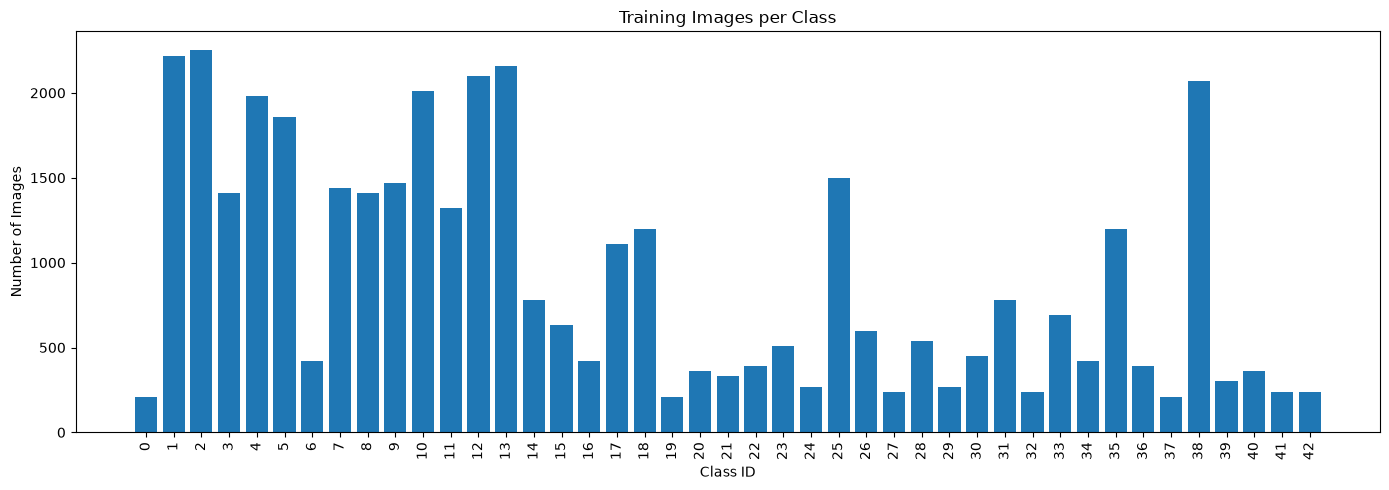

In [20]:
hf.plot_class_distribution(
    train_class_counts,
    label_col="ClassId",
    count_col="image_count",
    title="Training Images per Class"
)

### 3.4 Test Class Distribution Check

We will also check the test CSV class distribution.

We will not use the test set for model selection, but understanding its class balance helps us know what final evaluation will look like.

Test class distribution summary:


count     43.000000
mean     293.720930
std      233.442389
min       60.000000
25%       90.000000
50%      180.000000
75%      450.000000
max      750.000000
Name: image_count, dtype: float64

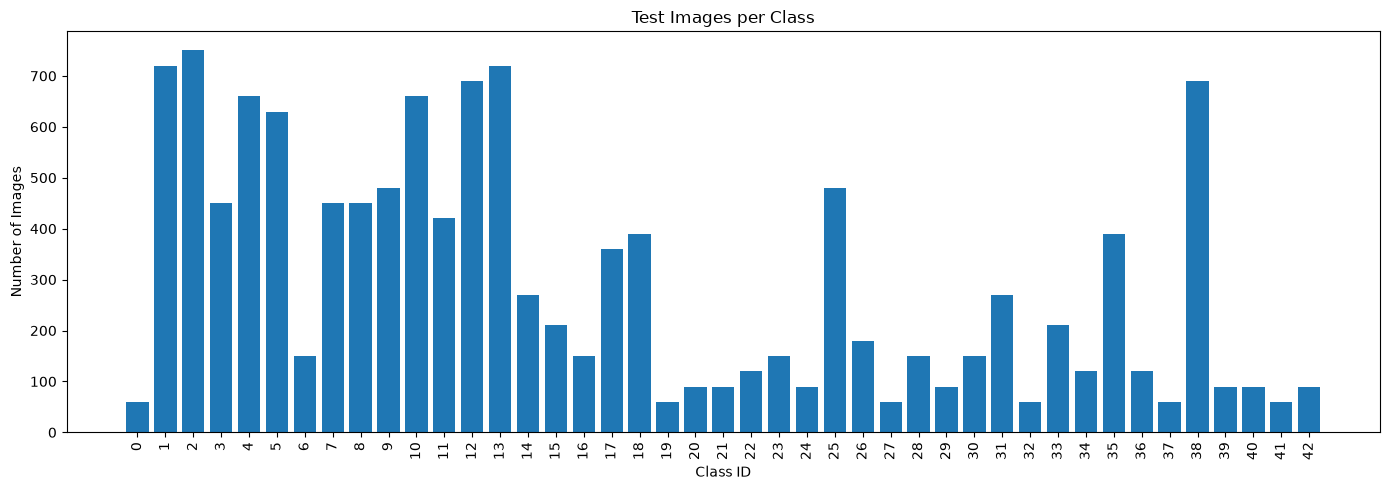

In [21]:
print("Test class distribution summary:")
display(test_class_counts["image_count"].describe())

hf.plot_class_distribution(
    test_class_counts,
    label_col="ClassId",
    count_col="image_count",
    title="Test Images per Class"
)

### 3.5 Save class distribution tables

The class distribution section creates several small summary tables.

Instead of keeping every table only inside the notebook output, we will save them into one Excel file.  
This will make the notebook cleaner and also keep the analysis tables available for later reporting.

In [23]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [24]:
importlib.reload(hf)

analysis_tables_path = REPORT_DIR / "gtsrb_analysis_tables.xlsx"

class_distribution_tables = {
    "train_class_counts": train_class_counts,
    "train_count_summary": train_class_counts["image_count"].describe().reset_index(),
    "smallest_train_classes": train_class_counts.sort_values("image_count").head(10),
    "largest_train_classes": train_class_counts.sort_values("image_count", ascending=False).head(10),
    "test_class_counts": test_class_counts,
    "test_count_summary": test_class_counts["image_count"].describe().reset_index(),
}

hf.save_tables_to_excel(class_distribution_tables, analysis_tables_path)

Saved 6 tables to: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Report\gtsrb_analysis_tables.xlsx


### 3.6 Class Distribution Observation and Decision

**What this shows:**  
The training and test sets both contain all 43 classes, but the number of images per class is not equal. Some classes have many more images, while some classes have very few images.

**Why this matters:**  
This means the model may learn majority classes more easily than minority classes. If we only look at overall accuracy, the model can look good even when it performs poorly on smaller classes.

This also means evaluation should not depend only on accuracy. Later, we should use:

- confusion matrix
- classification report
- per-class accuracy
- wrong prediction analysis

**Decision:**  
For validation, we should keep class balance in mind. Since we already found `track_id`, we should try to create a validation split that is both class-aware and group-aware.

For evaluation, we will not trust accuracy alone. We will check which traffic sign classes the model confuses most.

### 3.7 Image Size Distribution

Now we will inspect the image width and height values from the CSV files.

This matters because PyTorch DataLoaders need images in the same tensor shape inside each batch.  
If image sizes are different, we must resize them during transforms.

In [25]:
importlib.reload(hf)

train_size_tables = hf.get_image_size_summary(train_df)
test_size_tables = hf.get_image_size_summary(test_df)

display(train_size_tables["size_summary"])
display(train_size_tables["unique_size_count"])

,index,Width,Height
0,count,39209.000000,39209.000000
1,mean,50.835880,50.328930
2,std,24.306933,23.115423
3,min,25.000000,25.000000
4,25%,35.000000,35.000000
5,50%,43.000000,43.000000
6,75%,58.000000,58.000000
7,max,243.000000,225.000000


,metric,value
0,unique_widths,187
1,unique_heights,176
2,unique_width_height_pairs,2924


### 3.8 Plot Image Size Distribution

A plot will help us quickly understand whether image sizes are consistent or highly variable.

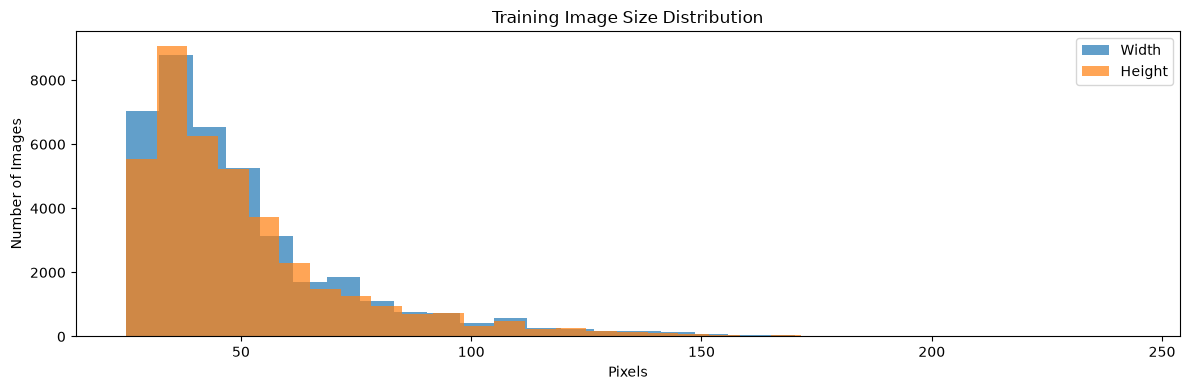

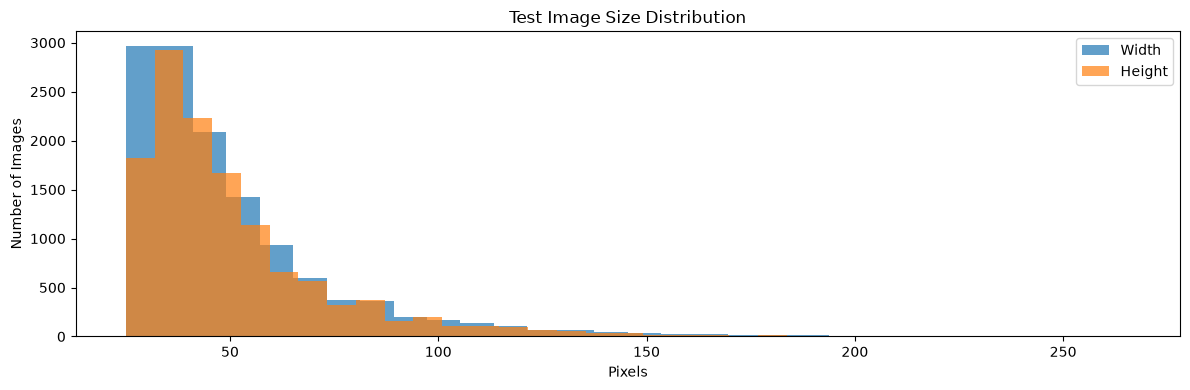

In [26]:
hf.plot_image_size_distribution(train_df, title_prefix="Training Image Size")
hf.plot_image_size_distribution(test_df, title_prefix="Test Image Size")

### 3.9 Save image size tables

We will save the image size summary tables into the same Excel analysis file.

This keeps the notebook clean while preserving the small analysis tables for reporting.

In [27]:
image_size_tables = {
    "train_size_summary": train_size_tables["size_summary"],
    "train_common_sizes": train_size_tables["most_common_sizes"],
    "train_unique_sizes": train_size_tables["unique_size_count"],
    "test_size_summary": test_size_tables["size_summary"],
    "test_common_sizes": test_size_tables["most_common_sizes"],
    "test_unique_sizes": test_size_tables["unique_size_count"],
}

hf.save_or_update_tables_to_excel(image_size_tables, analysis_tables_path)

Saved or updated 6 tables to: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Report\gtsrb_analysis_tables.xlsx


### 3.10 Image Size Observation and Decision

**What this shows:**  
The training and test images have variable width and height. Most images are small, but there are also some larger images in both sets.

**Why this matters:**  
PyTorch DataLoader cannot create a batch if images have different tensor shapes. For CNN training, every image in a batch must have the same shape such as `[3, 64, 64]`.

The train and test image size distributions look similar, which is good. It means the model will likely see a similar image-size pattern during training and final testing.

**Decision:**  
We will resize all images to a fixed size during transforms.

For the first baseline model, we will use:

- `Resize((64, 64))`
- `ToTensor()`

This keeps the pipeline simple and fast. Later, if needed, we can test larger image sizes such as `96x96` or use padding-based resizing to reduce distortion.

### 3.11 Random Training Image Samples

Now we will display random training images.

This helps us visually inspect image quality, lighting variation, scale differences, and whether labels are being connected correctly.

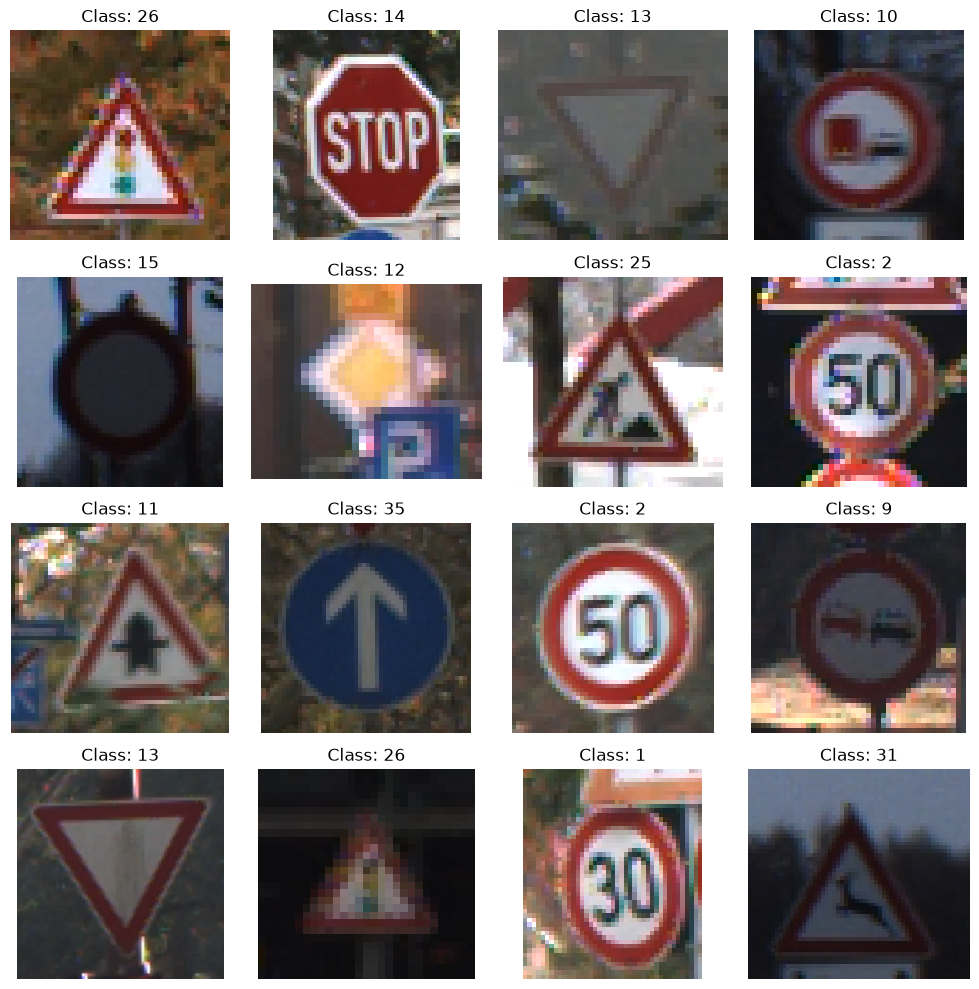

In [28]:
importlib.reload(hf)

hf.show_random_images(
    train_df,
    image_col="full_path",
    label_col="ClassId",
    n=16,
    seed=SEED,
    cols=4,
    figsize=(10, 10)
)

### 3.12 One Image from Selected Classes

Random images are useful, but they may not show many different classes.

Here, we will display one image from selected classes to get a better visual sense of class variety.

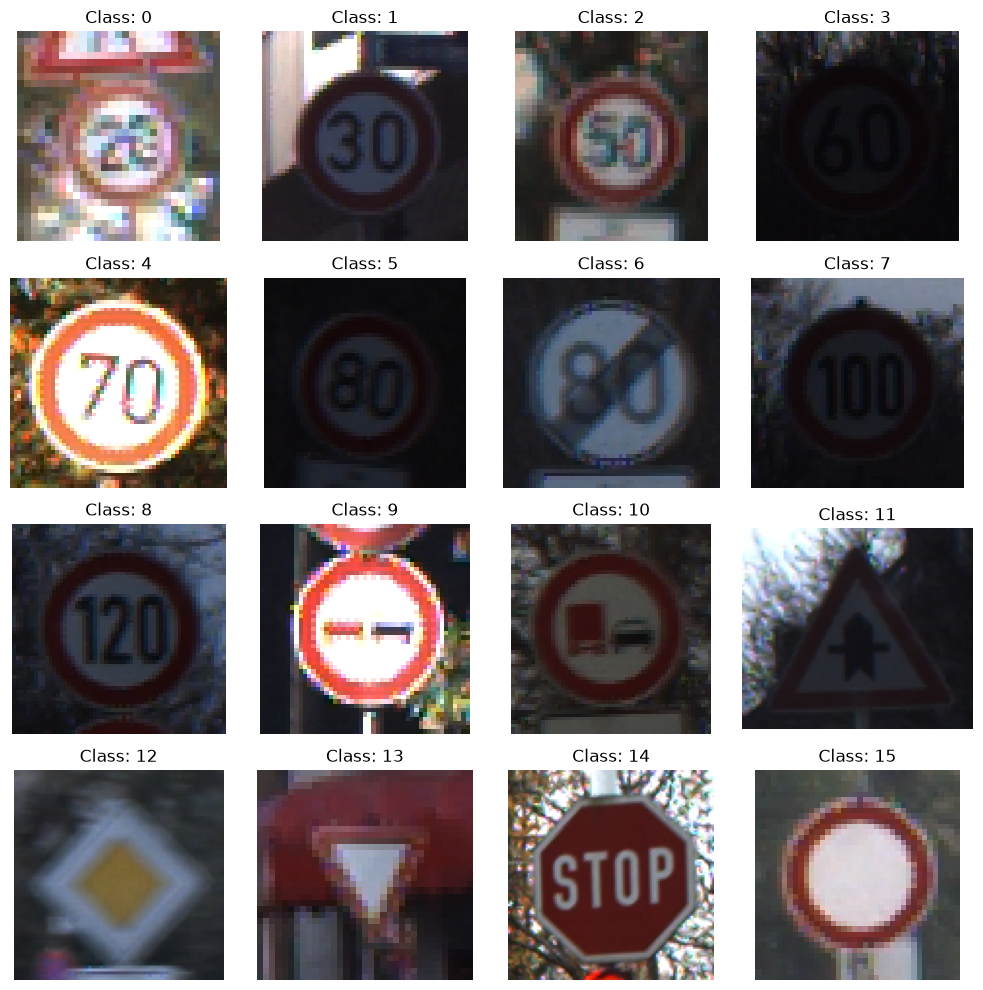

In [29]:
hf.show_one_image_per_class(
    train_df,
    image_col="full_path",
    label_col="ClassId",
    max_classes=16,
    seed=SEED,
    cols=4,
    figsize=(10, 10)
)

### 3.13 Visual Image Sample Observation and Decision

**What this shows:**  
The traffic sign images are not perfectly clean. Many images are small, pixelated, blurry, dark, overexposed, or partly affected by background and lighting conditions.

Some signs are visually easy to recognize, such as the stop sign, but many classes are more difficult because the sign is dark, blurred, or very small inside the image. There are also several visually similar signs, especially speed-limit signs and triangular warning signs.

**Why this matters:**  
This means the model needs to learn from real-world noisy images, not clean textbook images. A simple CNN may still work, but evaluation should carefully check wrong predictions because some errors may come from poor image quality rather than only weak model learning.

This also affects preprocessing and augmentation decisions:

- We must resize all images to a fixed size before batching.
- We should use moderate augmentation later to improve robustness.
- We should avoid aggressive transformations that destroy sign meaning.
- Horizontal flip should be avoided because some traffic signs can change meaning when flipped.
- Color and brightness variation are important because many images have different lighting conditions.

**Decision:**  
For the baseline model, we will keep preprocessing simple:

- Resize images to `64x64` . we can also use `96x96` ... when we will use transfer learning we will use `224x224`
- Convert images to tensors
- Do not use heavy augmentation yet

After the baseline, we can test a second experiment with safe augmentation such as small rotation, small translation, and brightness/contrast changes.

We should also include wrong prediction analysis later, because this dataset contains blurry and visually confusing samples.

In [30]:
IMAGE_SIZE = 96

## 4. Data Preparation

Now we will prepare the data for PyTorch training.

In this section, we will create a validation split from the training data.  
The official test set will not be used for model selection. It will be kept for final evaluation.

### Main goals

- Create a train/validation split
- Avoid putting very similar images in both train and validation
- Check class distribution after splitting
- Prepare a clean plan for transforms and PyTorch Dataset creation

### 4.1 Validation Split Strategy

The training data contains multiple very similar images under the same `track_id`.

If we split randomly by image, images from the same track may appear in both training and validation.  
That would make validation accuracy less honest.

So, we will use a group-aware split based on `track_id`.

### Guiding questions

- Can we split the data without sharing `track_id` between train and validation?
- Does the validation split still contain all 43 classes?
- Is the class distribution still reasonable after splitting?

### 4.2 Create Grouped Train/Validation Split

Now we will create a validation split from `train_df`.

We will use `track_id` as the group column so that the same track does not appear in both training and validation.

In [31]:
importlib.reload(hf)

train_split_df, valid_split_df = hf.create_grouped_train_valid_split(
    train_df,
    label_col="ClassId",
    group_col="track_id",
    n_splits=5,
    seed=SEED
)

print("Train split shape:", train_split_df.shape)
print("Valid split shape:", valid_split_df.shape)

Train split shape: (31349, 10)
Valid split shape: (7860, 10)


### 4.3 Check Split Quality

After creating the split, we need to check whether it is usable.

A good validation split should:

- have no overlapping `track_id`
- contain all 43 classes
- keep a reasonable class distribution

In [32]:
split_tables = hf.check_split_quality(
    train_split_df,
    valid_split_df,
    label_col="ClassId",
    group_col="track_id"
)

display(split_tables["split_overview"])
display(split_tables["leakage_check"])
display(split_tables["split_class_balance"].head())

,split,num_images,num_classes,num_groups
0,train,31349,43,1045
1,valid,7860,43,262


,metric,value
0,overlapping_groups,0


,ClassId,image_count_train,image_count_valid,valid_ratio
0,0,180,30,0.142857
1,1,1770,450,0.202703
2,2,1800,450,0.200000
3,3,1140,270,0.191489
4,4,1590,390,0.196970


### 4.4 Save Split Tables

The split summary tables are small but important.

We will save them into the project-level Excel workbook so we can review the split quality later.

In [35]:
split_tables_path = REPORT_DIR / "04_data_preparation_split_tables.xlsx"

split_tables_to_save = {
    "split_overview": split_tables["split_overview"],
    "leakage_check": split_tables["leakage_check"],
    "split_class_balance": split_tables["split_class_balance"],
}

hf.save_or_update_tables_to_excel(split_tables_to_save, split_tables_path)

Saved or updated 3 tables to: c:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Deep_Learning\Pytorch-German-Traffic-Sign-Recognition\Report\04_data_preparation_split_tables.xlsx


### 4.5 Quick Class Balance Plot After Split

Now we will plot the training and validation class distributions separately.

This helps us visually check whether the validation split still represents all classes.

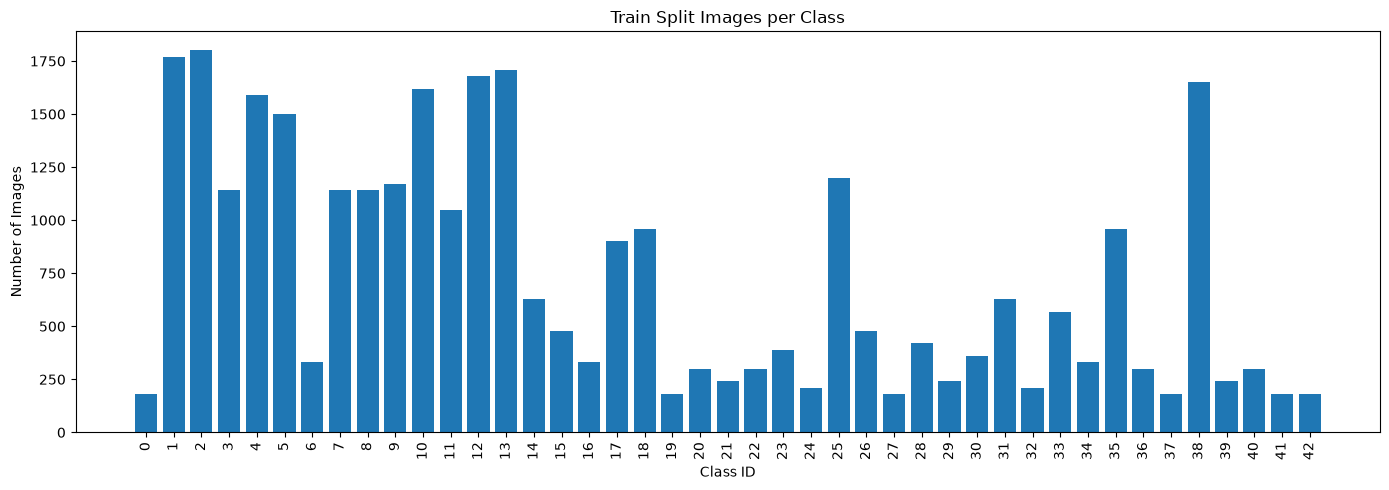

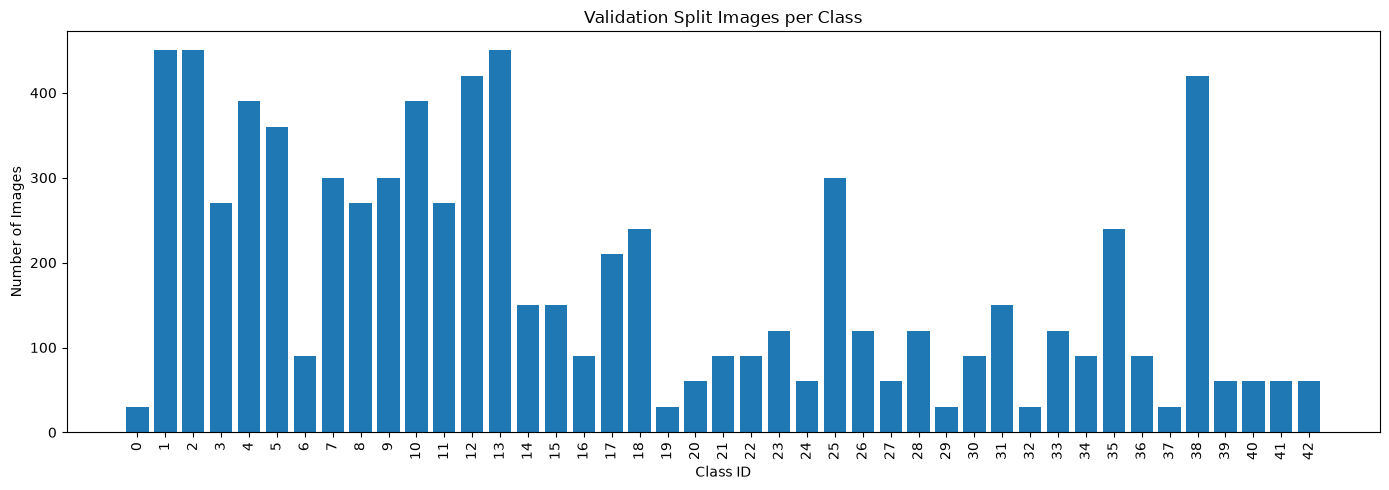

In [34]:
train_split_counts = hf.get_class_distribution(train_split_df, label_col="ClassId")
valid_split_counts = hf.get_class_distribution(valid_split_df, label_col="ClassId")

hf.plot_class_distribution(
    train_split_counts,
    label_col="ClassId",
    count_col="image_count",
    title="Train Split Images per Class"
)

hf.plot_class_distribution(
    valid_split_counts,
    label_col="ClassId",
    count_col="image_count",
    title="Validation Split Images per Class"
)

### 4.6 Split Observation and Decision

**What this shows:**  
The grouped train/validation split looks usable. Both the training split and validation split contain the same 43 traffic sign classes, and the class distribution pattern is similar in both splits.

The validation set is smaller, but it still follows the original imbalance pattern of the dataset.

**Why this matters:**  
This is better than a simple random image-level split because we used `track_id` to avoid placing very similar image groups in both train and validation.

This makes validation performance more honest. If the model performs well on this validation split, it is more likely learning general traffic sign patterns rather than memorizing near-duplicate images.

However, the dataset is still imbalanced. Some classes have many more images than others, so later we should not rely only on overall accuracy.

**Decision:**  
We will use this grouped train/validation split for model development.

The official test set will remain untouched until final evaluation.

For evaluation, we will later use:

- validation accuracy
- loss curves
- confusion matrix
- per-class analysis
- wrong prediction visualization